In [220]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ast

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    roc_auc_score,
)

from sklearn.naive_bayes import GaussianNB, CategoricalNB

from sklearn.preprocessing import MultiLabelBinarizer, label_binarize
from collections import Counter
from sklearn.dummy import DummyClassifier

In [221]:
# from scikitplot.metrics import plot_roc 
# from scikitplot.metrics import plot_precision_recall

from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.metrics import PrecisionRecallDisplay

Loading the datasets: we substitute `runtimeMinutes` for `logRuntime`.

In [222]:
# Train

df = pd.read_csv("../results/train_clean.csv", index_col=0)
df['countryOfOrigin'] = df['countryOfOrigin'].apply(ast.literal_eval)
df['genres'] = df['genres'].apply(ast.literal_eval)
df['logRuntime'] = np.log(df['runtimeMinutes'] + 1) 
df.drop(columns=['runtimeMinutes'], inplace=True)

In [223]:
# Test

df_test = pd.read_csv("../results/test_clean.csv", index_col=0)
df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval) 
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['logRuntime'] = np.log(df_test['runtimeMinutes'] + 1)
df_test.drop(columns=['runtimeMinutes'], inplace=True)

In [224]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16431 entries, 0 to 16430
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   originalTitle          16431 non-null  object 
 1   rating                 16431 non-null  object 
 2   startYear              16431 non-null  int64  
 3   numVotes               16431 non-null  float64
 4   totalImages            16431 non-null  float64
 5   totalCredits           16431 non-null  float64
 6   titleType              16431 non-null  object 
 7   canHaveEpisodes        16431 non-null  bool   
 8   numRegions             16431 non-null  float64
 9   countryOfOrigin        16431 non-null  object 
 10  genres                 16431 non-null  object 
 11  ratingNum              16431 non-null  int64  
 12  numGenres              16431 non-null  int64  
 13  criticReviewsRatio     16431 non-null  float64
 14  awardsAndNominations   16431 non-null  bool   
 15  hasVide

In [225]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5478 entries, 0 to 5477
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   originalTitle          5478 non-null   object 
 1   rating                 5478 non-null   object 
 2   startYear              5478 non-null   int64  
 3   numVotes               5478 non-null   float64
 4   totalImages            5478 non-null   float64
 5   totalCredits           5478 non-null   float64
 6   titleType              5478 non-null   object 
 7   canHaveEpisodes        5478 non-null   bool   
 8   numRegions             5478 non-null   float64
 9   countryOfOrigin        5478 non-null   object 
 10  genres                 5478 non-null   object 
 11  ratingNum              5478 non-null   int64  
 12  numGenres              5478 non-null   int64  
 13  criticReviewsRatio     5478 non-null   float64
 14  awardsAndNominations   5478 non-null   bool   
 15  hasVideos

# Target variable: titleType

## GaussianNB
We first implement a model that only uses numerical features (including `ratingNum`).

In [226]:
X_train = df.select_dtypes(include=['int64', 'float64']).values
y_train = df['titleType'].values

In [227]:
X_test = df_test.select_dtypes(include=['int64', 'float64']).values
y_test = df_test['titleType'].values

In [228]:
clf = GaussianNB()

In [229]:
%%time
clf.fit(X_train, y_train)

CPU times: total: 31.2 ms
Wall time: 34 ms


GaussianNB()

In [230]:
y_pred = clf.predict(X_test)
y_pred

array(['short', 'movie', 'tvSpecial', ..., 'movie', 'tvSeries', 'video'],
      shape=(5478,), dtype='<U12')

Let's compare the performance with a dummy model that predicts randomly, but respecting the class distribution in the training set. Our model performes significantly better (accuracy: 0.676 vs 0.233, macro F1: 0.398 vs 0.102).

Unsurprisingly, the target classes with a higher support have better performances, with the most popular class, `movie`, scoring >0.80 in all metrics. As expected, the class it is mostly mistaken for, with 98 misclassificated records, is `tvMovie`. The contrary is also true, with the relatively small `tvMovie` class being classified as `movie` most of the time.

The 2nd most popular class, `tvEpisode`, has a lower precision, at 0.70: its variable runtime leads to different misclassifications (mostly as `movie`, `short` or `tvSeries`).

The 3rd most popular class, `short`, performs almost as well as `movie` while having less than half its support: as we've seen in clustering, this class distinguishes itself from the others particularly well.

As for the remaining underrepresented classes, they get often misclassified as more popular classes with which they share some similarities: `tvShort` is almost always classified as `short` (for its runtime); `tvSpecial`, `tvSeries` and `tvMiniSeries` have largely been classified as `tvEpisode`; `videogame` has a good precision but was also mistaken for `tvEpisode` a significant amount of times; `video`, being a broad classification for a dishomogenous set of titles, has been misclassified as different classes.


In [231]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

       movie      0.832     0.807     0.819      1877
       short      0.793     0.783     0.788       766
   tvEpisode      0.700     0.795     0.745      1599
tvMiniSeries      0.235     0.049     0.082        81
     tvMovie      0.215     0.124     0.157       299
    tvSeries      0.415     0.306     0.353       447
     tvShort      0.000     0.000     0.000        16
   tvSpecial      0.070     0.265     0.110        49
       video      0.245     0.308     0.273       250
   videoGame      0.862     0.532     0.658        94

    accuracy                          0.676      5478
   macro avg      0.437     0.397     0.398      5478
weighted avg      0.676     0.676     0.672      5478



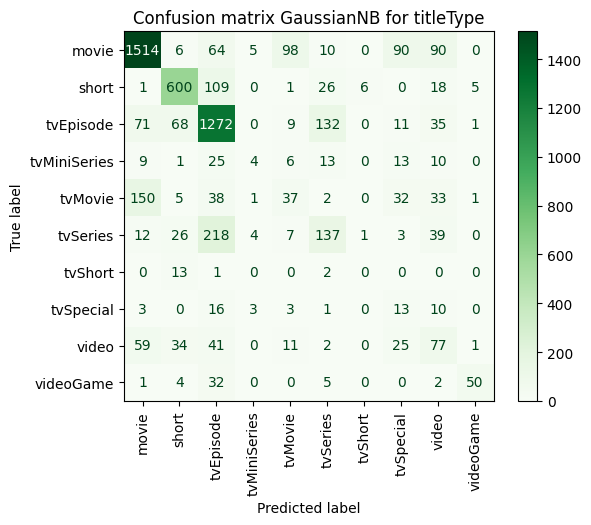

In [232]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred, y_true=y_test,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.title("Confusion matrix GaussianNB for titleType")
plt.show()

In [233]:
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(X_train, y_train)
dummy_y_pred = dummy_clf.predict(X_test)
print(classification_report(y_test, dummy_y_pred, digits=3))


              precision    recall  f1-score   support

       movie      0.353     0.331     0.341      1877
       short      0.162     0.183     0.172       766
   tvEpisode      0.275     0.282     0.278      1599
tvMiniSeries      0.027     0.025     0.026        81
     tvMovie      0.059     0.057     0.058       299
    tvSeries      0.076     0.081     0.078       447
     tvShort      0.000     0.000     0.000        16
   tvSpecial      0.016     0.020     0.018        49
       video      0.035     0.032     0.033       250
   videoGame      0.013     0.011     0.012        94

    accuracy                          0.233      5478
   macro avg      0.102     0.102     0.102      5478
weighted avg      0.236     0.233     0.234      5478



On ROC curves:

They use FPR on the x-axis, which is a problem for unbalanced data. This problem is accentuated for our multiclass task: in one-vs-rest, the positive class is always by far the minority. Since the negative class becomes largely predominant, the FPR barely surpasses 0 before we have a 100% TPR.

This is clear looking at tvShort: although our model had a 0% recall and precision for this class, its AUC score is 0.93.

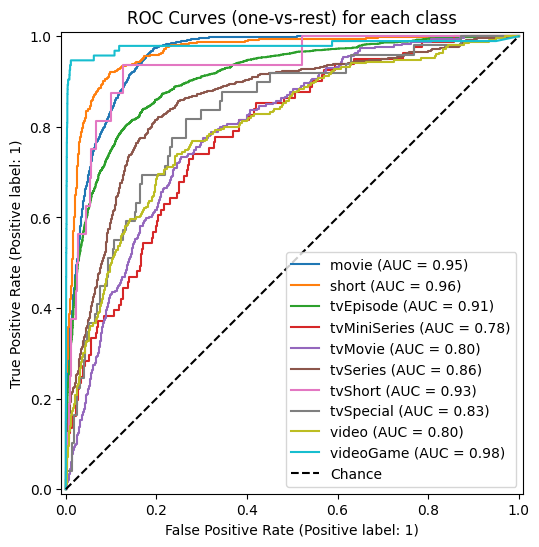

Macro-average ROC AUC: 0.880


In [234]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(X_test) #predicted probabilities


plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_name}",
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.legend()
plt.title("ROC Curves (one-vs-rest) for each class")
plt.show()

auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print(f"Macro-average ROC AUC: {auc_score:.3f}")


## CategoricalNB

### Pre-processing
As with `GaussianNB`, all features must be transformed into numpy arrays. Further preprocessing:

- Categorical features
  - We don't use `originalTitle` and `rating` (bc we're using `ratingNum`).
  - Multi-label variables: We binarize  `countryOfOrigin` and `genres`. Since `countryOfOrigin` has many unique values, we only keep the 40 most frequent to reduce dimensionality and noise from rare countries, collapsing all other countries to 'Other'.
  - Ordinal: We treat `ratingNum` as a numeric variable. Since it is already a discretization, we create a bin for each unique value, for a total of 10.
  - Boolean: Keep as is.

- Numeric features: we discretize them into four quantile-based bins (ie. quartiles). 

Multi-label categorical features:

In [235]:
mbl = MultiLabelBinarizer()

In [236]:
all_countries = [country for countries in df['countryOfOrigin'] for country in countries]
country_counts = Counter(all_countries) #Counter: dictionary 'country':count
"country_counts.most_common(45)" #list of tuples

top_n_countries = 40
top_countries = set([country for country, _ in country_counts.most_common(top_n_countries)]) 

def clean_countries(countries):
    return [c if c in top_countries else "Other" for c in countries]

df['country_cleaned'] = df['countryOfOrigin'].apply(clean_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_countries)

In [237]:
countries_df = pd.DataFrame(mbl.fit_transform(df['country_cleaned']), columns=mbl.classes_, index=df.index)
genres_df = pd.DataFrame(mbl.fit_transform(df['genres']), columns=mbl.classes_, index=df.index)

countries_df_test = pd.DataFrame(mbl.fit_transform(df_test['country_cleaned']), columns=mbl.classes_, index=df_test.index)
genres_df_test = pd.DataFrame(mbl.fit_transform(df_test['genres']), columns=mbl.classes_, index=df_test.index)

In [238]:
# into numpy arrays
array_countries = countries_df.values
array_countries_test = countries_df_test.values

array_genres = genres_df.values
array_genres_test = genres_df_test.values

Boolean features:

In [239]:
bool_cols = [
    'canHaveEpisodes',
    'awardsAndNominations',
    'hasVideos',
    'moreCountriesOfOrigin'
]

array_bool = df[bool_cols].values
array_bool_test = df_test[bool_cols].values

Ordinal feature (`ratingNum`):

In [240]:
# [0,9) instead of [1,10)
rating_binned = (df['ratingNum'] - 1).values.reshape(-1, 1)
rating_binned_test = (df_test['ratingNum'] - 1).values.reshape(-1, 1)

In [241]:
rating_binned

array([[7],
       [5],
       [5],
       ...,
       [5],
       [3],
       [9]], shape=(16431, 1))

Numeric features (no `ratingNum`):

In [242]:
numeric_cols = df.dtypes[(df.dtypes == 'float64') | (df.dtypes == 'int64')].index
numeric_cols = numeric_cols.drop('ratingNum')  

X_numeric = df[numeric_cols].values
X_numeric_test = df_test[numeric_cols].values

In [243]:
X_train_binned = []

for column_idx in range(X_numeric.shape[1]):
    X_train_binned.append(pd.qcut(X_numeric[:, column_idx], q=4, labels=False, duplicates='drop'))


In [244]:
X_test_binned = []

for column_idx in range(X_numeric_test.shape[1]):
    X_test_binned.append(pd.qcut(X_numeric_test[:, column_idx], q=4, labels=False, duplicates='drop'))

In [245]:
X_train_binned = np.array(X_train_binned).T
X_test_binned = np.array(X_test_binned).T

In [246]:
print(X_train_binned.shape, X_test_binned.shape)

(16431, 8) (5478, 8)


In [247]:
X_train_final = np.hstack([X_train_binned, rating_binned, array_countries, array_genres, array_bool])
X_test_final = np.hstack([X_test_binned, rating_binned_test, array_countries_test, array_genres_test, array_bool_test])

In [248]:
print(X_train_final.shape, X_test_final.shape)

(16431, 82) (5478, 82)


### Model

In [249]:
#to avoid IndexError when using CategoricalNB

min_categories = [ 
    np.unique(X_train_final[:, i]).size + 1  # only fitted on training data, but +1 for possible unseen categories in test
    for i in range(X_train_final.shape[1])
]

In [250]:
clf = CategoricalNB(min_categories=min_categories) # min_categories: maximum number of bins allocated to each feature
# clf = CategoricalNB(min_categories=4) 
clf.fit(X_train_final, y_train)

CategoricalNB(min_categories=[5, 5, 4, 5, 3, 3, 3, 5, 11, 3, 3, 3, 3, 3, 3, 3,
                              3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...])

In [251]:
y_pred = clf.predict(X_test_final)

Using categorical features as well as numeric features has proved to be beneficial: we have a better performance than by using Gaussian NB (accuracy: 0.773 vs 0.676, macro F1: 0.557 vs 0.398).

The performance for `tvShort` has remained exactly the same, due to the almost negligible number of records. `videogame` has a lower macro F1, but has now more balanced values for precision and recall and has been correctly classified as itself more times. 
The performance for all other classes improves. The three most popular classes now all have macro F1 values > 0.80, and `short` has a great gain in recall (0.923).

`tvMiniSeries` and `tvSeries` have the most dramatic improvement in performance, with the latter scoring the highest precision (0.921) and F1 (0.904). They are now both correctly classified most of the time. Now `tvMiniSeries` only gets misclassified as `tvSeries` (around 42% of the time), whereas `tvSeries` mostly gets mistaken for `tvMiniSeries`, but only 9% of the time: the model has managed to distinguish them from `tvEpisode`.

In [252]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

       movie      0.830     0.825     0.827      1877
       short      0.827     0.923     0.872       766
   tvEpisode      0.870     0.777     0.821      1599
tvMiniSeries      0.534     0.580     0.556        81
     tvMovie      0.316     0.281     0.297       299
    tvSeries      0.921     0.888     0.904       447
     tvShort      0.000     0.000     0.000        16
   tvSpecial      0.200     0.367     0.259        49
       video      0.404     0.508     0.450       250
   videoGame      0.504     0.691     0.583        94

    accuracy                          0.773      5478
   macro avg      0.541     0.584     0.557      5478
weighted avg      0.783     0.773     0.776      5478



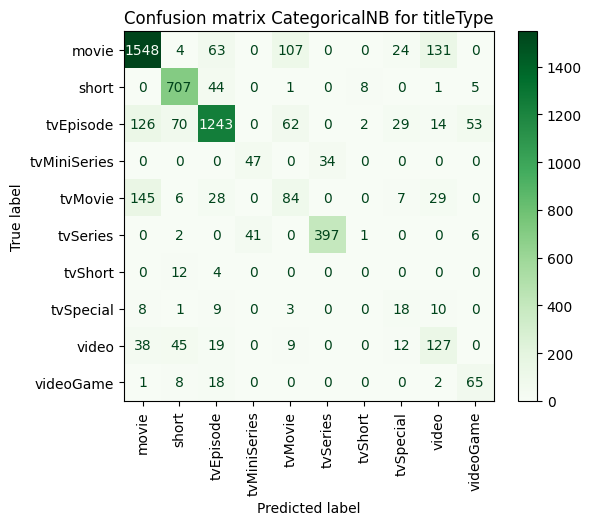

In [253]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred, y_true=y_test,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.title("Confusion matrix CategoricalNB for titleType")
plt.show()

ROC curve: same critique as before.

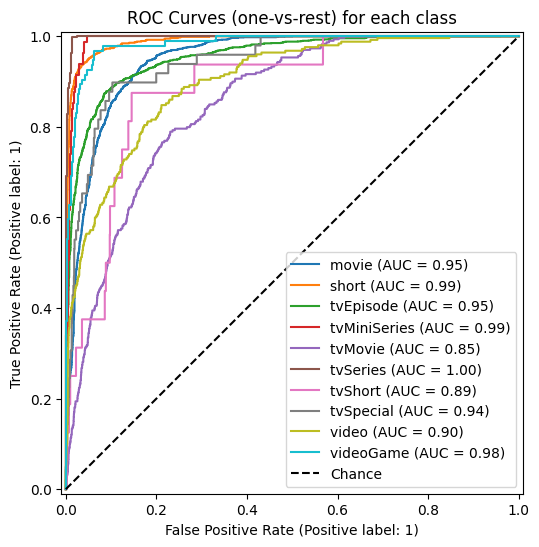

Macro-average ROC AUC: 0.944


In [ ]:
#classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(X_test_final)


plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_name}",
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.legend()
plt.title("ROC Curves (one-vs-rest) for each class")
plt.show()

auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print(f"Macro-average ROC AUC: {auc_score:.3f}")

# Target variable: rating

In [255]:
y_train = df['rating'].values
y_test = df_test['rating'].values

## GaussianNB

In [256]:
clf = GaussianNB()

In [257]:
%%time
clf.fit(X_numeric, y_train)

CPU times: total: 31.2 ms
Wall time: 30 ms


GaussianNB()

In [258]:
y_pred = clf.predict(X_numeric_test)
y_pred

array(['(8, 9]', '(7, 8]', '(0, 1]', ..., '(7, 8]', '(7, 8]', '(0, 1]'],
      shape=(5478,), dtype='<U7')

In [259]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

      (0, 1]      0.000     0.000     0.000         1
      (1, 2]      0.000     0.000     0.000        20
      (2, 3]      0.000     0.000     0.000        52
      (3, 4]      0.000     0.000     0.000       155
      (4, 5]      0.349     0.096     0.151       384
      (5, 6]      0.325     0.085     0.135       930
      (6, 7]      0.337     0.335     0.336      1522
      (7, 8]      0.366     0.591     0.452      1608
      (8, 9]      0.199     0.059     0.092       690
     (9, 10]      0.127     0.147     0.136       116

    accuracy                          0.298      5478
   macro avg      0.170     0.131     0.130      5478
weighted avg      0.308     0.298     0.274      5478



c:\Users\camim\anaconda3\envs\dm1_project\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\camim\anaconda3\envs\dm1_project\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\camim\anaconda3\envs\dm1_project\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

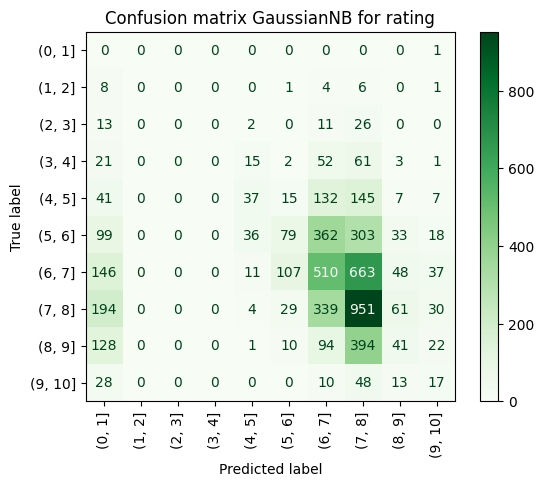

In [260]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred, y_true=y_test,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.title("Confusion matrix GaussianNB for rating")
plt.show()

The models performs slightly better than a dummy classifier (macro F1: 0.13 vs 0.10). We assume it is due to the unbalanced distribution of the rating classes in the dataset.

In [261]:
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(X_numeric, y_train)
dummy_y_pred = dummy_clf.predict(X_numeric_test)
print(classification_report(y_test, dummy_y_pred, digits=3))


              precision    recall  f1-score   support

      (0, 1]      0.000     0.000     0.000         1
      (1, 2]      0.034     0.050     0.041        20
      (2, 3]      0.000     0.000     0.000        52
      (3, 4]      0.018     0.019     0.019       155
      (4, 5]      0.083     0.091     0.087       384
      (5, 6]      0.175     0.177     0.176       930
      (6, 7]      0.261     0.260     0.261      1522
      (7, 8]      0.299     0.292     0.296      1608
      (8, 9]      0.119     0.114     0.117       690
     (9, 10]      0.028     0.026     0.027       116

    accuracy                          0.210      5478
   macro avg      0.102     0.103     0.102      5478
weighted avg      0.212     0.210     0.211      5478



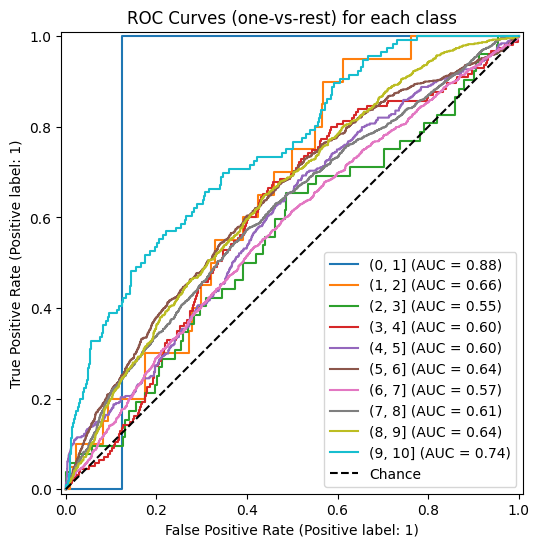

Macro-average ROC AUC: 0.649


In [262]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(X_numeric_test)


plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_name}",
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.legend()
plt.title("ROC Curves (one-vs-rest) for each class")
plt.show()

auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print(f"Macro-average ROC AUC: {auc_score:.3f}")

## CategoricalNB

We add `titleType` to the feature set (and, of course, remove `ratingNum`). Being a categorical variable, we one-hot encode it.

In [263]:
array_titleType = pd.get_dummies(df['titleType']).values
array_titleType_test = pd.get_dummies(df_test['titleType']).values

In [264]:
X_train_final = np.hstack([X_train_binned, array_titleType, array_countries, array_genres, array_bool])
X_test_final = np.hstack([X_test_binned, array_titleType_test, array_countries_test, array_genres_test, array_bool_test])

In [265]:
min_categories = [ 
    np.unique(X_train_final[:, i]).size + 1  
    for i in range(X_train_final.shape[1])
]

In [266]:
clf = CategoricalNB(min_categories=min_categories) 
clf.fit(X_train_final, y_train)

CategoricalNB(min_categories=[5, 5, 4, 5, 3, 3, 3, 5, 3, 3, 3, 3, 3, 3, 3, 3, 3,
                              3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...])

In [267]:
y_pred = clf.predict(X_test_final)

In [268]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

      (0, 1]      0.000     0.000     0.000         1
      (1, 2]      0.000     0.000     0.000        20
      (2, 3]      0.033     0.058     0.042        52
      (3, 4]      0.120     0.155     0.135       155
      (4, 5]      0.134     0.078     0.099       384
      (5, 6]      0.302     0.395     0.342       930
      (6, 7]      0.343     0.256     0.293      1522
      (7, 8]      0.449     0.521     0.483      1608
      (8, 9]      0.261     0.177     0.211       690
     (9, 10]      0.125     0.284     0.174       116

    accuracy                          0.330      5478
   macro avg      0.177     0.192     0.178      5478
weighted avg      0.327     0.330     0.323      5478



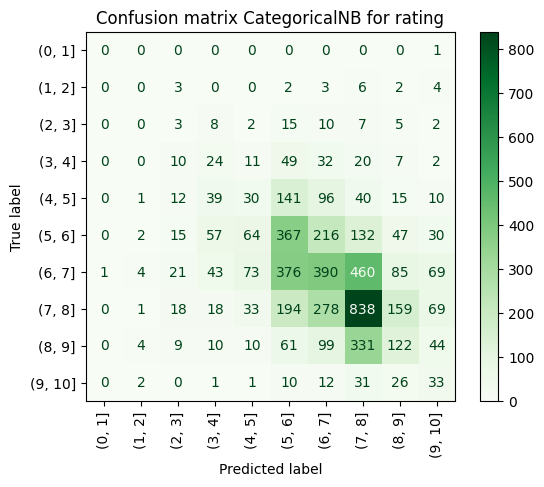

In [269]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred, y_true=y_test,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.title("Confusion matrix CategoricalNB for rating")
plt.show()

The model performs slightly better.

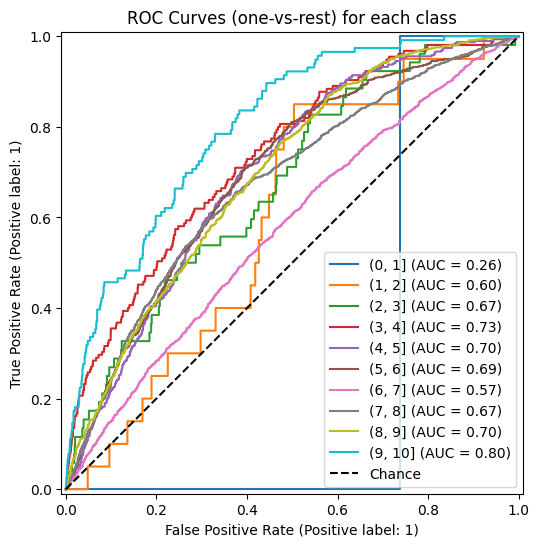

Macro-average ROC AUC: 0.641


In [270]:
#classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(X_test_final)


plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_name}",
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.legend()
plt.title("ROC Curves (one-vs-rest) for each class")
plt.show()

auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print(f"Macro-average ROC AUC: {auc_score:.3f}")

# Target variable: binned rating (low – medium-low – medium-high – high)

In [271]:
df['rating'].value_counts().sort_index()

rating
(0, 1]        5
(1, 2]       62
(2, 3]      154
(3, 4]      466
(4, 5]     1151
(5, 6]     2789
(6, 7]     4565
(7, 8]     4822
(8, 9]     2071
(9, 10]     346
Name: count, dtype: int64

In order to have a more balanced distribution of our target class labels, and hopefully improve performances, we bin `ratingNum` as following:

In [272]:
# 2 BINS -> ACCURACY AND MACRO F1 AROUND 0.63 FOR GAUSSIAN AND 0.69 FOR CATEGORICAL
"""
def bin_rating(r):
    if r <= 7:
        return 0 #'Low'
    else:
        return 1 #'High'
"""

"\ndef bin_rating(r):\n    if r <= 7:\n        return 0 #'Low'\n    else:\n        return 1 #'High'\n"

In [273]:
# 3 BINS 
# Gauss: 0.56 acc, 0.43 macro f1
# Cat: 0.57 acc, 0.49 macro f1

# 'Low' is still underrepresented

"""
def bin_rating(r):
    if r <= 5:
        return 0 #'Low'
    elif r <= 7:
        return 1 #'Medium'
    else:
        return 2 #'High'
"""

"\ndef bin_rating(r):\n    if r <= 5:\n        return 0 #'Low'\n    elif r <= 7:\n        return 1 #'Medium'\n    else:\n        return 2 #'High'\n"

In [274]:
"""
y_train = (df['ratingNum'].apply(bin_rating)).values
y_test = (df_test['ratingNum'].apply(bin_rating)).values
"""

"\ny_train = (df['ratingNum'].apply(bin_rating)).values\ny_test = (df_test['ratingNum'].apply(bin_rating)).values\n"

In [275]:
# 4 BINS
pd.qcut(df['ratingNum'], 4).value_counts().sort_index()

ratingNum
(0.999, 6.0]    4627
(6.0, 7.0]      4565
(7.0, 8.0]      4822
(8.0, 10.0]     2417
Name: count, dtype: int64

In [276]:
df['ratingCat'] = pd.qcut(df['ratingNum'], 4, labels=(1, 2, 3, 4))
df_test['ratingCat'] = pd.qcut(df_test['ratingNum'], 4, labels=(1, 2, 3, 4))

target_feat = 'ratingCat'
y_train = df[target_feat]
y_test = df_test[target_feat]

In [277]:
pd.Series(y_train).value_counts().sort_index()

ratingCat
1    4627
2    4565
3    4822
4    2417
Name: count, dtype: int64

## GaussianNB

In [278]:
clf = GaussianNB()

In [279]:
%%time
clf.fit(X_numeric, y_train)

CPU times: total: 15.6 ms
Wall time: 8 ms


GaussianNB()

In [280]:
y_pred = clf.predict(X_numeric_test)
y_pred

array([4, 3, 4, ..., 3, 3, 4], shape=(5478,))

In [281]:
class_labels = ['Low', 'Medium-Low', 'Medium-High', 'High']

The model performs better than our dummy classifier (accuracy: 0.345 vs 0.264, macro f1: 0.33 vs 0.248). 
The confusion matrix shows how there's confusion amongst all classes, in particular w.r.t 'Medium-High', the most popular class (which is the one with the best recall and F1). 'Medium-Low' has a particularly low recall (0.173): its records are classifies more frequently as any other class (especially as 'Medium-High and 'Low) than as itself. 
'High' and 'Medium-High' mostly are confused amongst themselves.

In [282]:
print(classification_report(
    y_test, y_pred, digits=3,
    target_names= class_labels
))

              precision    recall  f1-score   support

         Low      0.389     0.336     0.361      1542
  Medium-Low      0.334     0.173     0.228      1522
 Medium-High      0.377     0.494     0.428      1608
        High      0.251     0.388     0.305       806

    accuracy                          0.345      5478
   macro avg      0.338     0.348     0.330      5478
weighted avg      0.350     0.345     0.335      5478



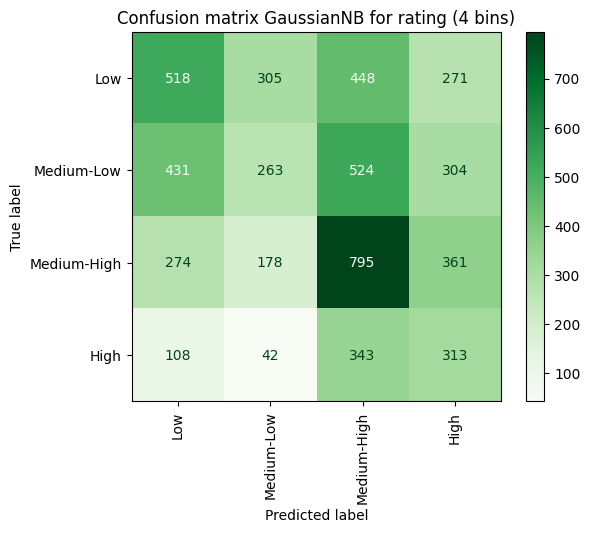

In [283]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred, y_true=y_test,
                                        xticks_rotation=90,
                                        cmap='Greens',
                                        display_labels=class_labels)
plt.title("Confusion matrix GaussianNB for rating (4 bins)")
plt.show()

In [284]:
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(X_numeric, y_train)
dummy_y_pred = dummy_clf.predict(X_numeric_test)
print(classification_report(
    y_test, dummy_y_pred, digits=3,
    target_names= class_labels
))

              precision    recall  f1-score   support

         Low      0.277     0.268     0.273      1542
  Medium-Low      0.267     0.275     0.271      1522
 Medium-High      0.305     0.312     0.309      1608
        High      0.141     0.135     0.138       806

    accuracy                          0.264      5478
   macro avg      0.248     0.248     0.248      5478
weighted avg      0.263     0.264     0.263      5478



ROC curve:

With fewer and more balanced classes, the graph becomes somewhat more meaningful.
We should still keep in mind its bias: 'High' seems to be the best performing one, but it's probably due to it being the less popular class + having a decent recall (wrt to the other classes).

'Medium-Low', on the other hand, has the lowest AUC score: it in fact has a very low recall, so its TPR struggles.


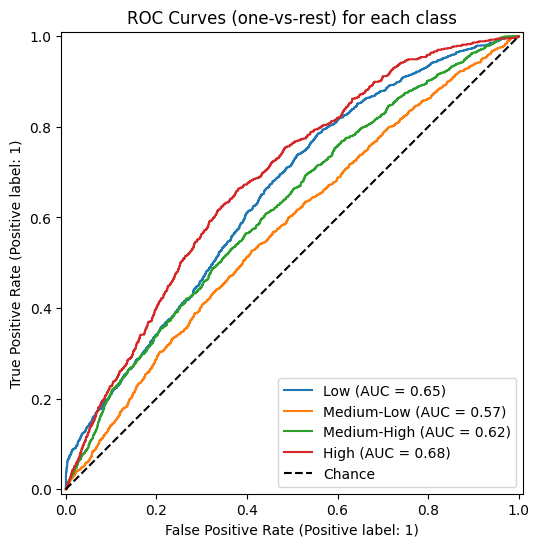

Macro-average ROC AUC: 0.630


In [285]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(X_numeric_test)

plt.figure(figsize=(8, 6))
for i, class_label in zip(range(len(classes)), class_labels):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=class_label,
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.legend()
plt.title("ROC Curves (one-vs-rest) for each class")
plt.show()

auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print(f"Macro-average ROC AUC: {auc_score:.3f}")

## CategoricalNB

In [286]:
clf = CategoricalNB(min_categories=min_categories) 
clf.fit(X_train_final, y_train)

CategoricalNB(min_categories=[5, 5, 4, 5, 3, 3, 3, 5, 3, 3, 3, 3, 3, 3, 3, 3, 3,
                              3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...])

In [287]:
y_pred = clf.predict(X_test_final)

The model's overall performance is better than the Gaussian's (accuracy: 0.427 vs 0.345, macro f1: 0.387 vs 0.33). 
'Low' is the class with the best improvement (f1 from 0.361 to 0.55): 2/3 of its records are now classified correctly, the misclassified records are quite balanced among the three remaining classes.

All other classes have has a slight decrease in macro F1.

'Medium-Low' has had a decrease in recall for a slight improvement in precision: less records are classified correctly, but now it is mostly confused with 'Low'.
'Medium-High' had a slight improvement in precision, at the cost of recall: 35 more records are classified correctly, but it is still quite confused with the other classes (now, especially with 'Low').
'High' has gained some precision at the cost of recall: less records are classified correctly, but the confusion has grown somewhat more stark between 'Medium-High' than the other two classes.

In [288]:
print(classification_report(
    y_test, y_pred, digits=3,
    target_names= class_labels
))

              precision    recall  f1-score   support

         Low      0.463     0.675     0.550      1542
  Medium-Low      0.381     0.151     0.216      1522
 Medium-High      0.457     0.516     0.485      1608
        High      0.294     0.297     0.295       806

    accuracy                          0.427      5478
   macro avg      0.399     0.410     0.387      5478
weighted avg      0.414     0.427     0.401      5478



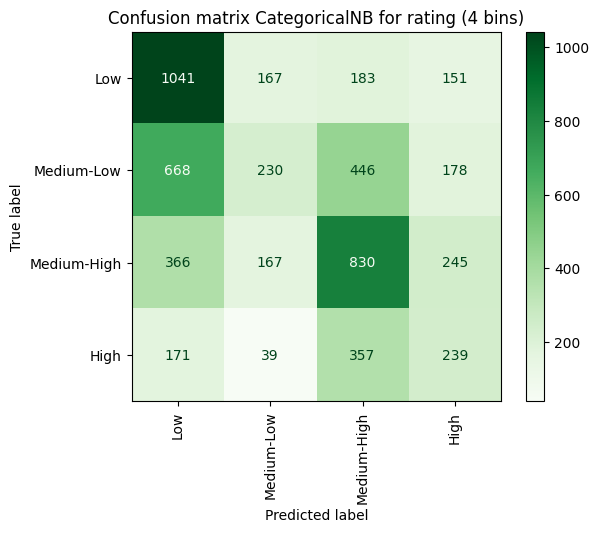

In [289]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred, y_true=y_test,
                                        xticks_rotation=90,
                                        cmap='Greens',
                                        display_labels=class_labels)
plt.title("Confusion matrix CategoricalNB for rating (4 bins)")
plt.show()

ROC curve:

The AUC score for all classes improves. This time, the models do not consistently outperform the others.

For a FPR lower than 0.5, the best performance is for 'Low', whereas for higher FPR (so for a less conservative model) it is surpassed by 'High'. 'Medium-Low''s AUC score hasn't improved much; in fact, its recall is still very low.


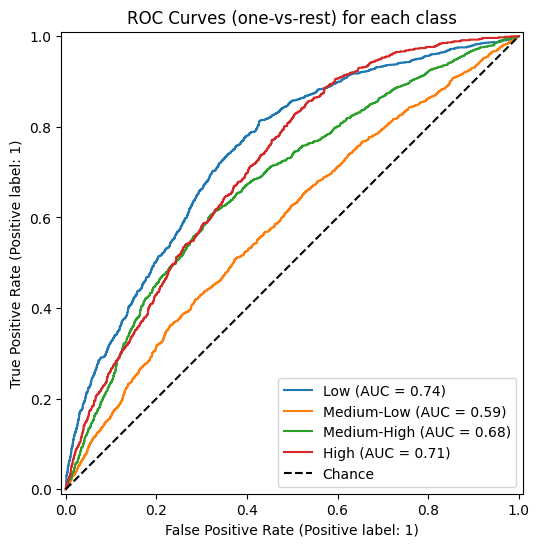

Macro-average ROC AUC: 0.680


In [290]:
#classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(X_test_final)

plt.figure(figsize=(8, 6))
for i, class_label in zip(range(len(classes)), class_labels):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=class_label,
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.legend()
plt.title("ROC Curves (one-vs-rest) for each class")
plt.show()

auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print(f"Macro-average ROC AUC: {auc_score:.3f}")